<a href="https://colab.research.google.com/github/ml4devs/ml4devs-notebooks/blob/master/llm/running_llm_locally.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center>Running LLMs Locally Using llama.cpp & Ollama</center></h1>

<p><center>
<address>&copy; Satish Chandra Gupta<br/>
LinkedIn: <a href="https://www.linkedin.com/in/scgupta/">scgupta</a>,
Twitter: <a href="https://twitter.com/scgupta">scgupta</a>
</address>
</center></p>

---

A hands-on demo notebook that runs local-LLM runtimes **live**:

| | Covers | Model used |
|---|---|---|
| **Setup** | Shared helpers. Run this first. | - |
| **Part 0** | Picking a model that fits your hardware (GPU VRAM or Mac unified memory). | - |
| **Part 1** | **llama.cpp**, the C/C++ engine most local tools are built on. GGUF and quantization. | Qwen2.5-3B, ~2 GB |
| **Part 2** | **Ollama**: one-line install, model management, OpenAI-compatible API. | Qwen2.5-3B, ~1.9 GB |
| **Part 3** | Text generation, including streaming. | Qwen3.5-4B, ~3.4 GB |
| **Part 4** | Image understanding with a multimodal model. | Gemma 4 E4B, ~9.6 GB |
| **Appendix** | **LM Studio** (desktop GUI) and cleaning up disk space. | - |

**Runs on Google Colab and on a local 16 GB machine (Windows / Linux / macOS).** The heaviest download is Gemma 4 E4B at ~9.6 GB; everything else is under 4 GB. Budget roughly 15 GB of free disk for the full notebook, and see the cleanup cell in the appendix for how to get it back. Cells are **safe to re-run**: installs and model pulls are skipped when already present, and the server is started only if it is not already up.

> **Read model sizes, not model names.** "E4B" means ~4B *effective* parameters, but the file you download is ~9.6 GB. Part 0 explains why, along with the same trap for mixture-of-experts models. Always confirm with `ollama list`.

> **LM Studio note:** LM Studio is a desktop GUI app and cannot run in Colab's headless VM. A short appendix shows the client code you would run against it locally. Everything here speaks the OpenAI API format, so client code barely changes across runtimes.

> **Model tags:** names like `qwen3.5:4b` and `gemma4:e4b` reflect July 2026 releases. The notebook pulls them defensively and **falls back to a known model** if a tag is unavailable, so it still runs end to end. Check current tags at [ollama.com/library](https://ollama.com/library).

---
### Before you start
- **On Colab:** for the fastest llama.cpp demo, enable a GPU via **Runtime -> Change runtime type -> Hardware accelerator -> GPU** (a free T4 is plenty). CPU works too, just slower.
- **On your own machine:** run the cells top to bottom. Backends (CUDA / Metal / CPU) and per-OS install are auto-detected.

## Setup - shared helpers

Run this cell first. It defines small, reusable helpers (idempotent installs, safe model pulls with
fallbacks, server health checks) so the rest of the notebook stays clean and re-runnable.

In [ ]:
# --- Shared helpers: run this cell first ---


import importlib
import os
import shutil
import subprocess
import sys
import time


def pip_install(*pkgs):
    """Install packages into THIS kernel's interpreter (correct even in local Jupyter).
    Returns True on success. On failure it PRINTS pip's error, so you get the real reason
    instead of a confusing ImportError several lines later."""
    proc = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *pkgs],
        capture_output=True,
        text=True
    )
    if proc.returncode != 0:
        print(f"[pip failed] {' '.join(pkgs)}")
        print((proc.stderr or proc.stdout).strip()[-1500:])
    return proc.returncode == 0


def ensure_import(module, pip_name=None):
    "Import a module, installing it once if missing. Returns the module."
    try:
        return importlib.import_module(module)
    except ImportError:
        pip_install(pip_name or module)
        return importlib.import_module(module)


def require(name, hint):
    """Fail with a useful message instead of a bare NameError when cells are run out of order.
    Notebooks get run non-linearly all the time; this says which cell to go back to."""
    value = globals().get(name)
    if value is None:
        raise RuntimeError(f"`{name}` is not set. Run the cell that {hint} first.")
    return value


def have(binary):
    "True if an executable is on PATH."
    return shutil.which(binary) is not None


def has_cuda():
    "True only if an NVIDIA GPU is actually usable."
    return have("nvidia-smi") and subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0


requests = ensure_import("requests")
os.environ.setdefault("OLLAMA_HOST", "127.0.0.1:11434")
OLLAMA_URL = "http://127.0.0.1:11434"


def ollama_up():
    "True if the Ollama server responds."
    try:
        return requests.get(f"{OLLAMA_URL}/api/version", timeout=2).ok
    except Exception:
        return False


def wait_for_ollama(seconds=60):
    """Poll until the server answers, giving up after `seconds` of WALL CLOCK time.
    (Counting loop iterations would not do that: each iteration also spends up to 2s
    inside the request timeout, so 60 iterations could mean 3 minutes.)"""
    deadline = time.time() + seconds
    while time.time() < deadline:
        if ollama_up():
            return True
        time.sleep(1)
    return False


def ollama_models():
    "List already-downloaded model tags (empty list if server is down)."
    try:
        data = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()
        return [m.get("name", "") for m in data.get("models", [])]
    except Exception:
        return []


def _canonical(tag):
    "Ollama reports an untagged name as ':latest'. Normalize before comparing."
    return tag if ":" in tag else f"{tag}:latest"


def pull_model(tag, fallbacks=()):
    """Ensure a model is available. Skip if already present; on failure try fallbacks.
    Returns a usable tag, or None if nothing worked."""

    present = {_canonical(n) for n in ollama_models()}
    for t in (tag, *fallbacks):
        # Match the FULL tag, not just the family name. qwen3.5:9b and qwen3.5:4b are
        # separate downloads, so treating one as proof of the other would report
        # "already available" and then 404 on the first chat call.
        if _canonical(t) in present:
            print(f"[ok]   {t} already available")
            return t
        print(f"[pull] {t} ...")
        if subprocess.run(["ollama", "pull", t], check=False).returncode == 0:
            return t
        print(f"[warn] could not pull {t}")
    print(f"[ERROR] none of {(tag, *fallbacks)} could be pulled. See https://ollama.com/library")
    return None


print("Helpers ready.")

Helpers ready.


## Part 0 - Choosing the right model for your hardware

The single biggest constraint is memory. A model needs roughly **0.5 GB per billion parameters at 4-bit (Q4)**, plus 15-20% for the KV cache and overhead at short context lengths. Long contexts push the KV cache much higher, so treat `n_ctx` as a memory knob, not just a quality knob. On a GPU that memory is VRAM; on Apple Silicon it is **unified memory shared with macOS and your apps**, so reserve ~5-6 GB for the system.

**Two traps that break the arithmetic:**

- **Count total parameters, not active ones.** Mixture-of-experts (MoE) models advertise a small "active" count, which is a *speed* figure. All the weights still have to be resident. Llama 4 Scout is "17B active" but 109B total, so it needs roughly 55-60 GB at Q4, not 9 GB.
- **Count the download, not the name.** Gemma 4 **E4B** means ~4B *effective* parameters, achieved by a technique that still ships far more weights. The actual Ollama download is **~9.6 GB**, not ~3 GB. After pulling anything, check the real number with `ollama list`.

Sizes below are measured download sizes where the notebook pulls the model.

### Desktop / laptop with an NVIDIA GPU (by VRAM)

| VRAM | Recommended | Also good |
|---|---|---|
| **8 GB** | Qwen3.5-9B (Q4, ~6.6 GB) fits, but leaves little room for context | Qwen3.5-4B (~3.4 GB) for long prompts, Qwen2.5-Coder 7B (code), Phi-4 Mini (reasoning), `llava` (vision, ~4.7 GB) |
| **12-16 GB** | Gemma 4 12B (Q4) | Qwen3.5-9B for headroom, **Gemma 4 E4B** (vision, ~9.6 GB) |
| **24 GB** (RTX 4090/3090) | **Qwen3.6-27B** (Q4, ~17 GB) | Gemma 4 31B |
| **40 GB+** | Qwen3.6-27B (Q8 / long context) or GLM-5.2 | higher precision or long context; 70B+ dense models and large MoE models such as Llama 4 Scout need this tier or multi-GPU |

### MacBook / Mac (by unified memory)

| Memory | Recommended | Notes |
|---|---|---|
| **16 GB Air** | **Qwen3.5-9B** (~6.6 GB) | Stay <=9B. **Qwen3.5-4B** (~3.4 GB) when you want lighter and faster; Gemma 4 E4B (~9.6 GB) fits, but only just |
| **24 GB Air** | Qwen3.5-9B / Qwen3-14B | Qwen3.5-27B only for short, high-value prompts (fanless throttle) |
| **32-36 GB** | Qwen3.6-27B / Gemma 4 26B | Frontier reasoning locally |
| **48 GB+** | Qwen3.6-27B / Gemma 4 31B | Comfortable headroom |

**Mac tips:** prefer **MLX** builds (LM Studio's MLX backend or `mlx-lm`); they run ~10-20% faster than llama.cpp. Note that Ollama itself only uses MLX on **32 GB+** Macs; on a 16 or 24 GB Mac it runs on Metal, so use LM Studio's MLX runtime or `mlx-lm` to get MLX there. The fanless Air throttles after ~20-30 min of continuous inference, so treat big models as a tool for short bursts.

The cell below detects whatever machine is running this notebook and prints a recommendation.

In [2]:
# Detect this machine and recommend a model.
# These thresholds mirror the tables above; keep the two in sync if you edit either.


import platform
import subprocess


psutil = ensure_import("psutil")


system = platform.system()
machine = platform.machine()
ram_gb = psutil.virtual_memory().total / (1024 ** 3)

# "Darwin" alone is not enough: Intel Macs have neither unified memory nor MLX,
# so they belong on the CPU path, not the Apple Silicon one.
is_apple_silicon = system == "Darwin" and machine in ("arm64", "aarch64")


vram_gb = 0.0
if have("nvidia-smi"):
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.total", "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL).decode().split()
        vram_gb = max(int(x) for x in out if x.isdigit()) / 1024
    except Exception:
        pass


def gpu_pick(v):
    if v >= 40: return "Qwen3.6-27B (Q8 / long context) or GLM-5.2 - higher precision; 70B+ dense and large MoE need multi-GPU"
    if v >= 24: return "Qwen3.6-27B (Q4, ~17 GB) - top desktop pick"
    if v >= 12: return "Gemma 4 12B (Q4) or Qwen3.5-9B (~6.6 GB); Gemma 4 E4B (~9.6 GB) for vision"
    if v >= 8:  return "Qwen3.5-9B (Q4, ~6.6 GB) - fits but tight; Qwen3.5-4B (~3.4 GB) for long prompts"
    return "Qwen3.5-4B (~3.4 GB) or smaller"


def mac_pick(r):
    if r >= 48: return "Qwen3.6-27B / Gemma 4 31B (Q4)"
    if r >= 32: return "Qwen3.6-27B (Q4, ~16 GB) or Gemma 4 26B"
    if r >= 24: return "Qwen3.5-9B / Qwen3-14B daily; Qwen3.5-27B for short prompts"
    if r >= 16: return "Qwen3.5-9B (Q4, ~6.6 GB); Qwen3.5-4B (~3.4 GB) when lighter"
    return "Qwen3.5-4B (~3.4 GB) or smaller"


print(f"OS: {system} ({machine}) | Python: {platform.python_version()} "
      f"| RAM: {ram_gb:.0f} GB | GPU VRAM: {vram_gb:.0f} GB\n")

if is_apple_silicon:
    print("Apple Silicon (unified memory).")
    print("  Recommended:", mac_pick(ram_gb))
    print("  Tip: prefer MLX builds; the fanless Air throttles after ~20-30 min.")
elif system == "Darwin":
    print("Intel Mac -> CPU inference. No unified memory, and MLX is Apple Silicon only.")
    print("  Recommended: Qwen3.5-4B (~3.4 GB) or smaller (expect slower tok/s).")
elif vram_gb >= 8:
    print("NVIDIA GPU detected.")
    print("  Recommended:", gpu_pick(vram_gb))
else:
    print("No usable GPU detected -> small models on CPU.")
    print("  Recommended: Qwen3.5-4B (~3.4 GB) or smaller (expect slower tok/s).")

OS: Darwin (arm64) | Python: 3.11.1 | RAM: 24 GB | GPU VRAM: 0 GB

Apple Silicon (unified memory).
  Recommended: Qwen3.5-9B / Qwen3-14B daily; Qwen3.5-27B for short prompts
  Tip: prefer MLX builds; the fanless Air throttles after ~20-30 min.


## Part 1 - llama.cpp

**llama.cpp is the engine.** Ollama (Part 2) and LM Studio (appendix) are both front ends built on
top of it. So this notebook is not three different ways to run a model, it is one inference engine
wrapped at three levels of convenience:

| | What it actually is | What you write |
|---|---|---|
| **llama.cpp** | the C/C++ inference engine | Python against a model object |
| **Ollama** | engine + model manager + HTTP server | OpenAI API calls |
| **LM Studio** | all of the above + a desktop GUI | OpenAI API calls |

That relationship is worth internalizing early: when a model runs slowly under Ollama, the fix is
almost always a llama.cpp-level knob (quantization, context length, GPU offload), not an Ollama
setting.

Below: install `llama-cpp-python` built for whatever backend this machine has (CUDA, Metal, or CPU),
download a quantized **GGUF** model from Hugging Face, and run a chat completion. On a 16 GB machine
the 3B demo model needs only ~2 GB. The install is skipped if it is already present.

In [ ]:
# Install llama-cpp-python from FIRST-PARTY PREBUILT WHEELS ONLY - never compiles.
# --only-binary=:all: guarantees pip will not fall back to a source build.
#
# Two things make this fiddlier than a normal pip install:
#
# 1. PyPI publishes ONLY a source tarball for llama-cpp-python, so a bare
#    "pip install --only-binary=:all: llama-cpp-python" finds nothing at all. Every
#    prebuilt wheel (CPU, Metal, CUDA) lives in the maintainer's index below.
#
# 2. Those wheels are tagged "py3-none-<platform>", which says NOTHING about CUDA. pip will
#    happily install a CUDA 13 build onto a CUDA 12 machine and report success. The failure
#    surfaces much later, at import time:
#        RuntimeError: Failed to load shared library '.../libllama.so':
#        libcudart.so.13: cannot open shared object file
#    So: pick the tag from what this machine can actually load, then VERIFY by importing
#    the result before accepting it. "pip succeeded" is not the same as "it works."


import ctypes
import importlib.util
import platform
import subprocess
import sys


WHEEL_INDEX = "https://abetlen.github.io/llama-cpp-python/whl"
# Published by the maintainer, newest first. cu132 -> CUDA 13.2 -> links libcudart.so.13
CUDA_TAGS = ["cu132", "cu130", "cu125", "cu124", "cu123", "cu122", "cu121", "cu118"]


def _tag_major(tag):
    "cu132 -> 13, cu124 -> 12, cu118 -> 11"
    return int(tag[2:]) // 10


def _loadable_cudart_majors():
    """CUDA runtime major versions the dynamic loader can actually find here.

    This is the ground truth, and it is NOT what nvidia-smi reports. The "CUDA Version"
    in nvidia-smi output is the highest release the DRIVER supports, not the runtime that
    is installed. A driver advertising 13.x on a machine that only ships libcudart.so.12
    is completely normal, and trusting that number is exactly how you end up with a cu132
    wheel that cannot load.

    If ctypes cannot dlopen the library, neither can libllama.so: same loader, same rules.
    """
    found = []
    for major in (13, 12, 11):
        try:
            ctypes.CDLL(f"libcudart.so.{major}")
            found.append(major)
        except OSError:
            continue
    return found


def _cuda_candidates(limit=3):
    "A short, ordered list of CUDA tags worth trying on this machine."
    majors = _loadable_cudart_majors()
    ranked = [t for t in CUDA_TAGS if _tag_major(t) in majors]
    if ranked:
        print(f"Detected CUDA runtime major version(s): {majors}")
        return ranked[:limit]
    # Some environments keep cudart off the default loader path, so an empty probe is not
    # proof of absence. Try the newest few; the import check below rejects what fails.
    print("Could not probe the CUDA runtime; trying the newest wheels and verifying each.")
    return CUDA_TAGS[:limit]


def _pip_wheel_only(backend):
    "pip install from the prebuilt-wheel index for `backend`. Returns True on success."
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--only-binary=:all:",
           "--extra-index-url", f"{WHEEL_INDEX}/{backend}", "llama-cpp-python"]
    return subprocess.run(cmd).returncode == 0


def _pip_uninstall():
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "llama-cpp-python"],
                   capture_output=True)


def _import_works():
    """Import llama_cpp in a FRESH process and touch the native library.

    A subprocess matters here: a half-broken native extension can leave this kernel in a
    state where retrying needs a restart. Testing out-of-process keeps failures disposable.
    """
    probe = "import llama_cpp; llama_cpp.llama_supports_gpu_offload()"
    return subprocess.run([sys.executable, "-c", probe], capture_output=True).returncode == 0


def _try_backend(backend):
    "Install one backend and keep it only if it actually imports."
    print(f"Trying prebuilt wheel: {backend} ...")
    if not _pip_wheel_only(backend):
        print(f"[warn] no {backend} wheel for this platform.")
        return False
    if _import_works():
        print(f"Installed and verified: {backend}")
        return True
    print(f"[warn] the {backend} wheel installed but will not load here; removing it.")
    _pip_uninstall()   # must remove it, or pip treats the requirement as already satisfied
    return False


def install_llama_cpp():
    # An existing install still has to be checked: a broken CUDA build from an earlier run
    # looks perfectly "installed" to find_spec and only fails when you import it.
    if importlib.util.find_spec("llama_cpp") is not None:
        if _import_works():
            print("llama-cpp-python already installed and loadable; skipping.")
            return True
        print("llama-cpp-python is installed but fails to load; reinstalling.")
        _pip_uninstall()

    if has_cuda():
        for tag in _cuda_candidates():
            if _try_backend(tag):
                return True
        print("No CUDA wheel loaded here; falling back to CPU (slower, but it works).")
    elif platform.system() == "Darwin":
        if _try_backend("metal"):
            return True
        print("No Metal wheel; falling back to CPU.")

    if _try_backend("cpu"):
        return True

    print("[WARN] No prebuilt wheel works on this platform. This notebook does NOT build")
    print("       from source by design - skip Part 1 and use the Ollama sections below,")
    print("       which have no such constraint.")
    return False


LLAMA_CPP_OK = install_llama_cpp()
ensure_import("huggingface_hub")

In [ ]:
# How many layers can we push onto the GPU?
#
# Ask the INSTALLED library, not the hardware. Those are different questions: a CPU-only
# wheel on a machine with an RTX 4090 must still use 0 GPU layers, and guessing from
# nvidia-smi would produce a model that fails to load.

N_GPU_LAYERS = 0

if not globals().get("LLAMA_CPP_OK"):
    print("llama-cpp-python is not usable here, so Part 1 will be skipped.")
    print("Re-run the install cell above; if it still fails, go straight to Part 2 (Ollama).")
    print("Nothing after Part 1 depends on it.")
else:
    import llama_cpp
    if llama_cpp.llama_supports_gpu_offload():
        N_GPU_LAYERS = -1  # -1 = offload every layer

    print("GPU offload available:", N_GPU_LAYERS == -1, "| n_gpu_layers:", N_GPU_LAYERS)
    print("(-1 offloads all layers; 0 is CPU-only. A partial number like 20 splits the model,")
    print(" which is how you run a model slightly too big for your VRAM.)")

### What is GGUF, and what does "Q4_K_M" mean?

You are about to download a file called `Qwen2.5-3B-Instruct-Q4_K_M.gguf`. Two ideas are packed
into that name, and both come up constantly once you start running models locally.

**GGUF** is llama.cpp's model format: weights, tokenizer, and metadata in a single file that can be
memory-mapped straight off disk. That is why local runtimes start quickly, and why one download
works unchanged across CPU, CUDA, and Metal.

**Q4_K_M** describes the quantization, read left to right:

| Piece | Meaning |
|---|---|
| `Q4` | weights stored at roughly 4 bits each, down from 16 |
| `_K` | "K-quant": a smarter scheme that spends more bits on the layers that are most sensitive to rounding |
| `_M` | the medium size within that family (`_S` is smaller and worse, `_L` larger and better) |

**Which to pick.** `Q4_K_M` is the sensible default: about a 4x size reduction for a quality loss
most people cannot detect in normal use. Two rules of thumb worth remembering:

- Below Q4 (Q3, Q2) quality falls off quickly. That is usually the signal to move to a *smaller model* rather than a more aggressive quantization of a big one.
- **For a fixed memory budget, a bigger model at Q4 usually beats a smaller model at Q8.** Spend your bytes on parameters before precision.

In [5]:
# Download a 4-bit GGUF of Qwen2.5-3B-Instruct (~2 GB, open / ungated). Cached after first run.

from huggingface_hub import hf_hub_download


model_path = None
try:
    model_path = hf_hub_download(
        repo_id="bartowski/Qwen2.5-3B-Instruct-GGUF",
        filename="Qwen2.5-3B-Instruct-Q4_K_M.gguf",
    )
    print("Model file:", model_path)
except Exception as e:
    print("[ERROR] download failed:", e)
    print("Check your network / Hugging Face availability, then re-run this cell.")

/Users/scgupta/.pyenv/versions/ml4devs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model file: /Users/scgupta/.cache/huggingface/hub/models--bartowski--Qwen2.5-3B-Instruct-GGUF/snapshots/f302c64a2269a69fb27b2f9473b362f5bb8e78d8/Qwen2.5-3B-Instruct-Q4_K_M.gguf


In [ ]:
# Load the model (GPU offload if available, else CPU) and run a chat completion. Safe to re-run.

if not globals().get("LLAMA_CPP_OK"):
    raise RuntimeError(
        "llama-cpp-python is not usable on this machine, so Part 1 cannot run. "
        "Re-run the install cell above, or skip to Part 2 (Ollama) - nothing later depends on it."
    )

from llama_cpp import Llama


model_path = require("model_path", "downloads the GGUF file")
n_layers = require("N_GPU_LAYERS", "checks GPU offload support")

# n_ctx is a memory knob as well as a quality one: the KV cache grows with it.
llm = Llama(model_path=model_path, n_gpu_layers=n_layers, n_ctx=4096, verbose=False)

out = llm.create_chat_completion(
    messages=[
        {"role": "system", "content": "You are a concise, helpful assistant."},
        {"role": "user", "content": "In 3 bullets, explain what quantization does for local LLMs."},
    ],
    max_tokens=256,
)
print(out["choices"][0]["message"]["content"])

In [ ]:
# Throughput check (tokens/sec).
#
# Part 3 runs the SAME measurement through Ollama so the two are directly comparable.
# Both warm up first and both report tok/s rather than wall-clock seconds, because
# wall clock mostly measures how long the answer happened to be.

import time


llm = require("llm", "loads the Llama model")
n_layers = require("N_GPU_LAYERS", "checks GPU offload support")

# Warm-up: absorbs one-off setup cost. Not timed.
llm.create_chat_completion(messages=[{"role": "user", "content": "ping"}], max_tokens=1)

t0 = time.time()
out = llm.create_chat_completion(
    messages=[{"role": "user",
               "content": "Write a haiku about running models locally, "
                          "then explain the imagery in two sentences."}],
    max_tokens=128,
)
dt = time.time() - t0

n = out["usage"]["completion_tokens"]
print(out["choices"][0]["message"]["content"])
print(f"\nllama.cpp: {n} completion tokens in {dt:.2f}s -> {n / dt:.1f} tok/s")
print(f"(n_gpu_layers={n_layers}; 0 means CPU-only, which is typically several times slower)")

Local models run,
Whispers in the quiet room,
Silent, strong, and true.

In this haiku, the first line symbolizes the process of running models locally, suggesting a quiet, internal process of computation. The second line personifies this process as a whisper, implying the subtle, almost imperceptible nature of local model execution. The final line emphasizes the strength and reliability of this local approach, likening it to a silent, steadfast presence.

llama.cpp: 93 completion tokens in 2.95s -> 31.5 tok/s
(n_gpu_layers=-1; 0 means CPU-only, which is typically several times slower)


In [8]:
# Free memory before starting Ollama so the two don't compete for VRAM.
#
# This UNLOADS the llama.cpp model on purpose. To run the Part 1 chat or throughput cells
# again afterwards, re-run the "Load the model" cell first. (You will not get a cryptic
# NameError if you forget: `require` says which cell to go back to.)

import gc


if globals().get("llm") is not None:
    del llm
    print("Released the llama.cpp model.")
else:
    print("No llama.cpp model is loaded; nothing to release.")

gc.collect()
try:
    import torch; torch.cuda.empty_cache()
except Exception:
    pass

Released the llama.cpp model.


## Part 2 - Ollama

Ollama installs with one script, runs a background server, and speaks the **OpenAI API format** on
port `11434`. Each step below is guarded: install only if missing, start the server only if it is not
already running.

In [9]:
# Install Ollama only if it is not already present.
# Note: ollama.com/install.sh is a LINUX script. macOS needs Homebrew or the .dmg.

import platform


system = platform.system()

if have("ollama"):
    print("Ollama already installed:", shutil.which("ollama"))
elif system == "Windows":
    print("Windows: install Ollama from https://ollama.com/download, then re-run this cell.")
elif system == "Darwin":
    if have("brew"):
        print("macOS: installing via Homebrew ...")
        subprocess.run(["brew", "install", "ollama"], check=False)
        print("Installed:", have("ollama"))
    else:
        print("macOS: install Ollama from https://ollama.com/download")
        print("       (or `brew install ollama`), then re-run this cell.")
else:
    print("Linux: installing Ollama ...")
    subprocess.run("curl -fsSL https://ollama.com/install.sh | sh", shell=True, check=False)
    print("Installed:", have("ollama"))

Ollama already installed: /opt/homebrew/bin/ollama


In [10]:
# Start the Ollama server only if it is not already running (idempotent).

if not have("ollama"):
    print("[ERROR] ollama binary not found - run the install cell above first.")
elif ollama_up():
    print("Ollama server already running.")
else:
    subprocess.Popen(["ollama", "serve"],
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("Starting Ollama server ...")
    if wait_for_ollama(60):
        print("Ollama is up:", requests.get(f"{OLLAMA_URL}/api/version").json())
    else:
        print("[ERROR] server did not come up within 60s; re-run this cell.")

Ollama server already running.


In [11]:
# Pull a small general model (skipped if already present) and call the OpenAI-compatible API.
# The SAME client code works against Ollama, llama.cpp's server, LM Studio, or a cloud API.
openai = ensure_import("openai")
client = openai.OpenAI(base_url=f"{OLLAMA_URL}/v1", api_key="ollama")  # key ignored locally

GENERAL_MODEL = pull_model("qwen2.5:3b")
if GENERAL_MODEL:
    out = client.chat.completions.create(
        model=GENERAL_MODEL,
        messages=[{"role": "user", "content": "Name three reasons to run an LLM locally."}],
    )
    print(out.choices[0].message.content)
else:
    print("Skipped: no general model available.")

[ok]   qwen2.5:3b already available
Sure! Here are three compelling reasons for running Large Language Models (LLMs) locally:

1. **Data Protection and Security**:
   - Running LLMs locally allows you to keep all data within your organization's control, which can be crucial in environments where strict data protection regulations apply. It prevents sensitive information from being exposed to third-party servers, thereby reducing the risk of security breaches or compliance issues.

2. **Control Over Resource Management**:
   - In a local setup, you have direct control over resources such as CPU power and memory allocation, which can be critical for optimizing performance based on your specific use case. This allows for setting the perfect balance between computational speed and cost-efficiency. Additionally, it enables fine-tuning the environment to handle specific input sizes or model configurations.

3. **Reducing Latency**:
   - For applications where real-time responses are paramoun

## Part 3 - Text with **Qwen3.5-4B**

Qwen3.5-4B is a fast, lightweight text model. At Q4 it loads in ~3 GB, which makes it the practical
choice for **16 GB machines** (including a 16 GB MacBook Air). It runs through the Ollama server we
already started. If the `qwen3.5:4b` tag is unavailable, the helper falls back to `qwen2.5:3b` so the
rest of the section still runs.

In [12]:
# Ensure the text model (with a safe fallback). TEXT_MODEL holds whatever we can actually use.
TEXT_MODEL = pull_model("qwen3.5:4b", fallbacks=["qwen2.5:3b"])
print("Using text model:", TEXT_MODEL)

[ok]   qwen3.5:4b already available
Using text model: qwen3.5:4b


In [13]:
# Example A - summarization.
client = require("client", "creates the OpenAI-compatible client (Part 2)")
TEXT_MODEL = require("TEXT_MODEL", "pulls the text model (top of Part 3)")

text = """Local LLMs let developers keep data on-device, avoid API costs, and work offline.
Quantization shrinks a model's memory footprint so it fits on consumer hardware. Tools like
Ollama and llama.cpp expose an OpenAI-compatible API, so application code stays portable."""

out = client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[
        {"role": "system", "content": "You summarize crisply."},
        {"role": "user", "content": f"Summarize in one sentence:\n\n{text}"},
    ],
)
print("SUMMARY:", out.choices[0].message.content)

SUMMARY: Quantization tools like Ollama and llama.cpp empower developers to run secure, cost-effective Local LLMs on consumer devices by using portable OpenAI-compatible interfaces.


In [ ]:
# Example B - a small coding task, timed the same way as the llama.cpp cell in Part 1.
#
# Two things distort a naive timing, and both are worth knowing:
#  1. The FIRST call loads the model from disk into memory. Timing that measures your SSD,
#     not the model, so we do an untimed warm-up call first.
#  2. Qwen3-family models can emit internal "thinking" tokens before the visible answer.
#     Those tokens cost time, so tokens/sec is a fairer measure than wall-clock seconds.

import time


client = require("client", "creates the OpenAI-compatible client (Part 2)")
TEXT_MODEL = require("TEXT_MODEL", "pulls the text model (top of Part 3)")

# Warm-up: loads the model into memory. Not timed.
client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[{"role": "user", "content": "ping"}],
    max_tokens=1,
)

t0 = time.time()
out = client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[{"role": "user",
               "content": "Write a Python function that returns the nth Fibonacci number iteratively."}],
)
dt = time.time() - t0

print(out.choices[0].message.content)

n = out.usage.completion_tokens
print(f"\nOllama ({TEXT_MODEL}): {n} completion tokens in {dt:.2f}s -> {n / dt:.1f} tok/s")
print("Compare with the llama.cpp tok/s in Part 1. Same engine underneath, so similar-sized")
print("models at the same quantization should land in the same ballpark.")



Ollama (qwen3.5:4b): 815 completion tokens in 87.59s -> 9.3 tok/s
Compare with the llama.cpp tok/s in Part 1. Same engine underneath, so similar-sized
models at the same quantization should land in the same ballpark.


### Example C - streaming

Every call so far waited for the complete answer before printing anything. Streaming emits each
token as it is produced. Total time is unchanged, but time-to-first-token drops to a fraction of a
second, which is the difference between a script that looks frozen and one that feels alive.

**This example uses Ollama's native API rather than the OpenAI-compatible one, and that choice is
the lesson.** `qwen3.5:4b` is a *reasoning* model: it runs a long internal "thinking" pass before
producing its visible answer. Measured on the machine this notebook was written on, same model,
same prompt:

| Endpoint | Can you turn thinking off? | First visible token |
|---|---|---|
| `/v1` (OpenAI-compatible) | No, the `think` field is dropped | **62 s** |
| `/api/chat` (native) with `"think": false` | Yes | **0.5 s** |

That is the tradeoff behind "everything speaks the OpenAI format." The compatibility layer is what
makes your application code portable, but it only carries the fields the OpenAI API defines, so
engine-specific controls do not survive the trip. Use the native API when you need one of those,
and the OpenAI format for everything else.

Sending `"think": false` to a model that has no reasoning mode is harmless; it is simply ignored.

In [ ]:
# Example C - streaming, via Ollama's native /api/chat so we can switch thinking off.

import json
import time


TEXT_MODEL = require("TEXT_MODEL", "pulls the text model (top of Part 3)")

t0 = time.time()
first_token_at = None
n_chunks = 0

with requests.post(
    f"{OLLAMA_URL}/api/chat",
    json={
        "model": TEXT_MODEL,
        "messages": [{"role": "user",
                      "content": "Explain what a KV cache is, in about 60 words."}],
        "think": False,   # skip the reasoning pass; ignored by non-reasoning models
        "stream": True,
    },
    stream=True,          # requests must ALSO stream, or it buffers the whole response
    timeout=300,          # and you lose the entire benefit without noticing
) as resp:
    for line in resp.iter_lines():
        if not line:
            continue
        chunk = json.loads(line)
        text = chunk.get("message", {}).get("content", "")
        if text:
            if first_token_at is None:
                first_token_at = time.time() - t0
            n_chunks += 1
            print(text, end="", flush=True)
        if chunk.get("done"):
            break

total = time.time() - t0
if first_token_at is None:
    print("[warn] the stream produced no text.")
else:
    print(f"\n\nfirst token after {first_token_at:.2f}s | {n_chunks} chunks | {total:.2f}s total")
    print("Example B printed nothing at all until it was completely finished.")

A Key-Value (KV) cache stores previously computed attention values during the processing of previous tokens. By reusing this cached information for subsequent input sequences instead of recalculating it, LLMs significantly reduce computational complexity and speed up inference while maintaining model accuracy through efficient reuse strategies like sliding windows or quantization.

first token after 1.87s | 63 chunks | 11.93s total
Example B printed nothing at all until it was completely finished.


## Part 4 - Image understanding with **Gemma 4 E4B**

Gemma 4 E4B is a small **multimodal** model that accepts images. The "E4B" name means ~4B
*effective* parameters, but the actual download is **~9.6 GB**, so it wants a 16 GB Mac or a
12 GB+ GPU rather than the 8 GB tier. This is the single most common sizing mistake with local
models: the parameter count in the name is not the memory footprint.

We generate a simple image locally, then ask the model to describe it, so there is no external
download. If `gemma4:e4b` is unavailable, the helper falls back to `llava` (a widely available
vision model, ~4.7 GB, which is also the better fit if you only have 8 GB of VRAM).

In [16]:
# Ensure a vision-capable model (with fallback).
VISION_MODEL = pull_model("gemma4:e4b", fallbacks=["llava"])
print("Using vision model:", VISION_MODEL)

[ok]   gemma4:e4b already available
Using vision model: gemma4:e4b


Wrote /var/folders/78/vm6z_gns4c990fs7dc9jx3lh0000gn/T/llm_demo_h_ccfgn6/sample.png


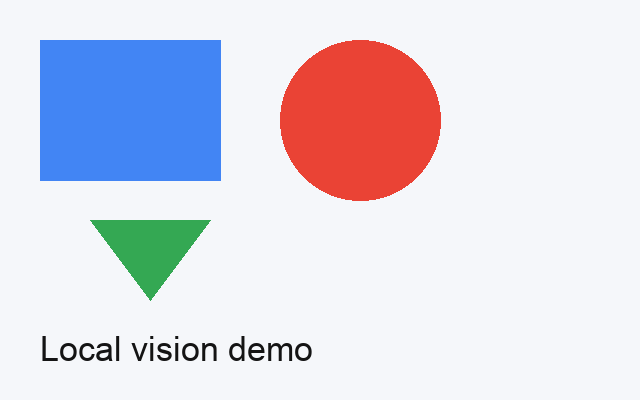

In [ ]:
# Create a simple test image with shapes and text (renders inline as the cell output).
#
# Font size matters more than anything else here. PIL's default font is an ~11px bitmap,
# which a vision model cannot read reliably at this canvas size - it will hallucinate
# plausible-looking text. If the model misreads your test image, suspect the image first.

ensure_import("PIL", "Pillow")

import os
import tempfile

from PIL import Image, ImageDraw, ImageFont


def load_font(size):
    "A readable font, with fallbacks across OSes and Pillow versions."
    for path in ("/System/Library/Fonts/Supplemental/Arial.ttf",      # macOS
                 "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",   # Linux / Colab
                 "C:\\Windows\\Fonts\\arial.ttf"):                    # Windows
        try:
            return ImageFont.truetype(path, size)
        except OSError:
            continue
    try:
        return ImageFont.load_default(size=size)   # Pillow >= 10.1
    except TypeError:
        print("[warn] old Pillow: falling back to the tiny default font; OCR may fail.")
        return ImageFont.load_default()


img = Image.new("RGB", (640, 400), (245, 247, 250))
d = ImageDraw.Draw(img)
d.rectangle([40, 40, 220, 180], fill=(66, 133, 244))               # blue rectangle
d.ellipse([280, 40, 440, 200], fill=(234, 67, 53))                 # red circle
d.polygon([(150, 300), (90, 220), (210, 220)], fill=(52, 168, 83)) # green triangle
d.text((40, 330), "Local vision demo", fill=(20, 20, 20), font=load_font(34))

# Write to a temp directory, NOT the working directory: a notebook should not drop
# stray files into whatever repo you happen to have it checked out in.
IMAGE_PATH = os.path.join(tempfile.mkdtemp(prefix="llm_demo_"), "sample.png")
img.save(IMAGE_PATH)
print("Wrote", IMAGE_PATH)
img

In [ ]:
# Call 1 - Ollama native REST API with an image (base64-encoded).

import base64


VISION_MODEL = require("VISION_MODEL", "pulls the vision model (top of Part 4)")
IMAGE_PATH = require("IMAGE_PATH", "creates the test image")

# Re-read the file here rather than reusing a variable from the cell above, so this cell
# stands on its own if you run it in isolation.
with open(IMAGE_PATH, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

resp = requests.post(
    f"{OLLAMA_URL}/api/chat",
    json={
        "model": VISION_MODEL,
        "messages": [{
            "role": "user",
            "content": "Describe this image: list the shapes, their colors, and any text.",
            "images": [b64],
        }],
        "stream": False,
    },
    timeout=120,
).json()
print(resp.get("message", {}).get("content", resp))

Based on the image provided, here is a description listing the shapes, their colors, and all visible text:

**Shapes and Colors:**
*   **Square:** A blue square located on the left side.
*   **Circle:** A red circle located on the right side, approximately level with the top of the green triangle.
*   **Triangle:** A green downward-pointing triangle located below the blue square.

**Text:**
*   "Local vision demo" (This text is positioned beneath the shapes).


In [ ]:
# Call 2 - the same task via the OpenAI-compatible endpoint (image passed as a data URI).
#
# Note the difference in shape: Ollama's native API takes a separate "images" list, while
# the OpenAI format puts the image inline in the message content as a typed part. Same
# model, same server, two wire formats. The OpenAI one is what ports to other providers.

import base64


client = require("client", "creates the OpenAI-compatible client (Part 2)")
VISION_MODEL = require("VISION_MODEL", "pulls the vision model (top of Part 4)")
IMAGE_PATH = require("IMAGE_PATH", "creates the test image")

with open(IMAGE_PATH, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()
data_uri = "data:image/png;base64," + b64

out = client.chat.completions.create(
    model=VISION_MODEL,
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": "What shapes and text do you see? Answer in one line."},
            {"type": "image_url", "image_url": {"url": data_uri}},
        ],
    }],
)
print(out.choices[0].message.content)

Blue square, red circle, green downward-pointing triangle, and the text "Local vision demo".


## Appendix - LM Studio (run on your own machine)

LM Studio is a **desktop app**, so it cannot run in Colab. Once it is running locally it exposes the
same OpenAI-compatible server, so the client code is nearly identical to the Ollama sections.

**On your own computer:**
1. Install LM Studio from [lmstudio.ai](https://lmstudio.ai).
2. Download a model in the app (on a 16 GB Mac, try `Qwen3.5-4B` or `Qwen3.5-9B`; On Mac, switch the runtime to **MLX**).
3. Open **Developer / Local Server** and **Start Server** (default port `1234`), or run `lms server start`.
4. Run this **locally** (not in Colab):

```python
from openai import OpenAI
client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
out = client.chat.completions.create(
    model="qwen3.5-4b",   # the id shown in LM Studio's server panel
    messages=[{"role": "user", "content": "Hello from LM Studio!"}],
)
print(out.choices[0].message.content)
```

---

### Recap

| Runtime / model | Size | Best for | Runs in Colab? |
|---|---|---|---|
| **llama.cpp** | - | Portable, embeddable, widest hardware | Yes |
| **Ollama** | - | Fastest start, model management | Yes |
| **Qwen3.5-4B** | ~3.4 GB | Fast text on 16 GB machines | Yes |
| **Gemma 4 E4B** | ~9.6 GB | Vision on a 16 GB Mac or a 12 GB+ GPU | Yes |
| **llava** | ~4.7 GB | Vision when you only have 8 GB of VRAM | Yes |
| **LM Studio** | - | GUI-first exploration on desktop | No (desktop app) |

**Picking a model:** match memory first (Part 0), then task. Size by the **download**, not the name: "E4B" is ~9.6 GB and a "17B active" MoE like Llama 4 Scout is really 109B of resident weights. On 16 GB stay around 4-9B (Qwen3.5-4B/9B); on a 24 GB GPU, Qwen3.6-27B is the top pick. All of these converge on the OpenAI API format, so your application code stays the same across them.

---

## Cleaning up - where the models live

Running out of disk is the most common thing that goes wrong a few days into experimenting with
local models. Downloads are large, nothing expires on its own, and the files are not where most
people look.

| What | Where |
|---|---|
| Ollama models | `~/.ollama/models` (macOS / Linux), `%USERPROFILE%\.ollama\models` (Windows) |
| The Part 1 GGUF | `~/.cache/huggingface` (Ollama does not manage this one) |

Two different resources are in play, and mixing them up causes confusion:

- **Disk** is what `ollama pull` consumes and `ollama rm` frees.
- **Memory** is what a model consumes once loaded. Ollama keeps a model resident for 5 minutes after the last request, then unloads it. `ollama ps` shows what is resident right now, `ollama stop` unloads it immediately, and the `keep_alive` field on an API call overrides the timeout (`"keep_alive": 0` unloads as soon as the response is done).

This notebook downloads roughly 15 GB in total.

In [20]:
# What this notebook left on your disk and in memory. Read-only: nothing is deleted here.
#
# Note the capture_output=True: a subprocess writes to the kernel's stdout, which Jupyter
# does NOT fold into this cell's output. Capture it and print it from Python, or the tables
# below either vanish or show up in the terminal running the kernel instead.


def run_text(*cmd):
    "Run a command and return its output as text, so it renders in the cell."
    proc = subprocess.run(cmd, capture_output=True, text=True)
    return (proc.stdout or proc.stderr).rstrip() or "(no output)"


if not have("ollama"):
    print("ollama not installed; nothing to report.")
else:
    print("=== On disk (ollama list) ===")
    print(run_text("ollama", "list"))

    print("\n=== Resident in RAM/VRAM right now (ollama ps) ===")
    print(run_text("ollama", "ps"))

# The Part 1 GGUF is managed by Hugging Face, not Ollama, so report it separately.
hf_cache = os.path.expanduser("~/.cache/huggingface/hub")
if os.path.isdir(hf_cache):
    total = sum(os.path.getsize(os.path.join(root, f))
                for root, _, files in os.walk(hf_cache)
                for f in files
                if not os.path.islink(os.path.join(root, f)))
    print(f"\n=== Hugging Face cache ===\n{hf_cache}: {total / 1e9:.1f} GB")

print("""
To reclaim space (run these yourself; this cell deliberately does not):

    ollama rm gemma4:e4b       # delete a model from disk (~9.6 GB for this one)
    ollama stop gemma4:e4b     # unload from memory, keep it on disk
    huggingface-cli delete-cache   # interactive cleanup of the Part 1 GGUF
""")

=== On disk (ollama list) ===
NAME               ID              SIZE      MODIFIED    
qwen2.5:3b         357c53fb659c    1.9 GB    6 hours ago    
qwen3.5:9b         6488c96fa5fa    6.6 GB    7 days ago     
llama3.2:latest    a80c4f17acd5    2.0 GB    7 days ago     
qwen3.5:4b         2a654d98e6fb    3.4 GB    7 days ago     
gemma4:e4b         c6eb396dbd59    9.6 GB    7 days ago

=== Resident in RAM/VRAM right now (ollama ps) ===
NAME          ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
gemma4:e4b    c6eb396dbd59    3.3 GB    100% GPU     4096       4 minutes from now

=== Hugging Face cache ===
/Users/scgupta/.cache/huggingface/hub: 3.1 GB

To reclaim space (run these yourself; this cell deliberately does not):

    ollama rm gemma4:e4b       # delete a model from disk (~9.6 GB for this one)
    ollama stop gemma4:e4b     # unload from memory, keep it on disk
    huggingface-cli delete-cache   # interactive cleanup of the Part 1 GGUF



---
<p>Copyright &copy 2026 <a href="https://www.linkedin.com/in/scgupta">Satish Chandra Gupta</a>.</p>
<img src="https://licensebuttons.net/l/by-nc-sa/3.0/88x31.png" align="left"/> <p>&nbsp;<a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">CC BY-NC-SA 4.0 International</a> License.</p>